# Regressão Linear

In [1]:
%load_ext blackcellmagic
from myst_nb import glue

In [2]:
import numpy as np
import matplotlib.pyplot as plt

<a id="fig_RL_fit_M"></a>
## Fit para diferentes valores de M

In [3]:
N = 10
Nt = 1400
xt = np.linspace(0.1, 1.5, Nt)
y_exato = 0.5 + 0.25 * np.cos(2 * np.pi * xt)
x = np.linspace(0.1, 1.5, N)
y = 0.5 + 0.25 * np.cos(2 * np.pi * x) + 0.06 * np.random.randn(N)
y_teste = 0.5 + 0.25 * np.cos(2 * np.pi * xt) + 0.06 * np.random.randn(Nt)

In [4]:
def RL_MQ(x, y, m):
    N = len(y)
    M = np.zeros((N, m + 1))
    iv = np.arange(0, m + 1)
    for i in range(N):
        M[i, :] = x[i] ** iv
    R = M.T @ M
    p = M.T @ y
    v = np.linalg.solve(R, p)
    e = y - M @ v
    return v, e

In [5]:
def TESTE_POL(v, xn):
    m = len(v)
    N = len(xn)
    yn = np.zeros(N)
    for i in range(m):
        yn = yn + v[i] * xn ** i
    return yn

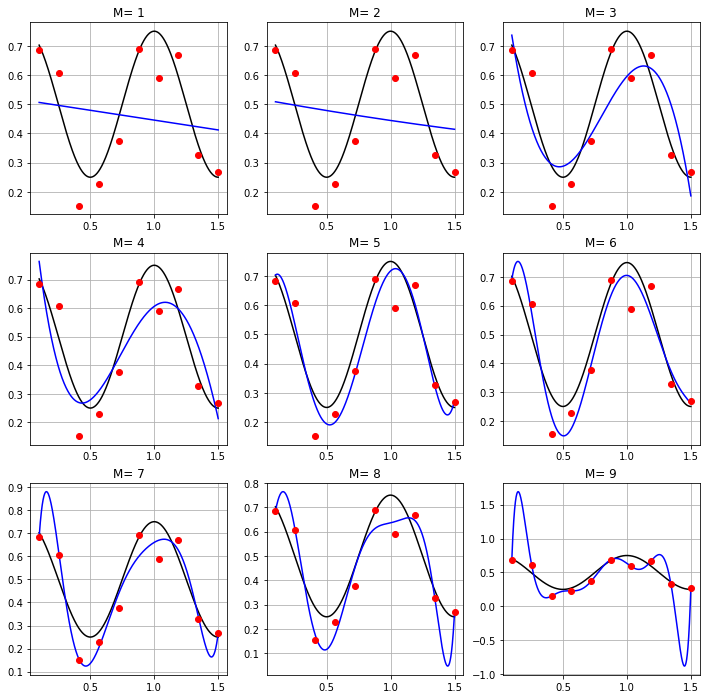

In [6]:
ordem = range(1, N)
erro_treino = np.zeros(N - 1)
erro_teste = np.zeros(N - 1)

fig = plt.figure(figsize=(12, 12))
for m in ordem:
    v, e = RL_MQ(x, y, m)
    yt = TESTE_POL(v, xt)

    erro_treino[m - 1] = np.sum(np.abs(e)) / N
    erro_teste[m - 1] = np.sum(np.abs(yt - y_teste)) / Nt
    plt.subplot(3, 3, m)
    plt.plot(xt, y_exato, "k")
    plt.plot(xt, yt, "b")
    plt.plot(x, y, "or")
    plt.grid()
    plt.title("M= " + str(m))

In [7]:
glue("fig_RL_fit_M", fig, display=False)

<a id="fig_RL_modulo_e_pred"></a>
## Módulo do erro de predição

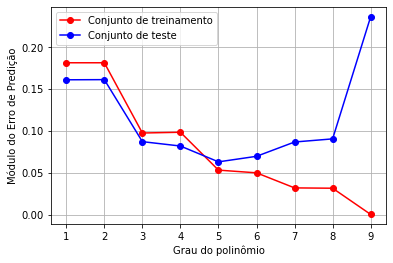

In [8]:
fig = plt.figure()
plt.plot(ordem, erro_treino, "-or", label="Conjunto de treinamento")
plt.plot(ordem, erro_teste, "-ob", label="Conjunto de teste")
plt.xlabel("Grau do polinômio")
plt.ylabel("Módulo do Erro de Predição")
plt.grid()
plt.legend()

In [9]:
glue("fig_RL_modulo_e_pred", fig, display=False)